In [1]:
import os
print(os.getcwd())

c:\Users\lilit\bluestock_mf_capstone\notebooks


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

In [3]:
nav = pd.read_csv("../data/processed/nav_history_clean.csv")
performance = pd.read_csv("../data/processed/performance_clean.csv")
benchmark = pd.read_csv("../data/processed/10_benchmark_indices.csv")

nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

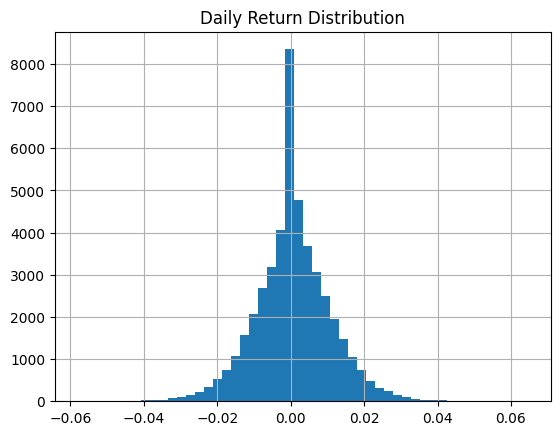

In [4]:
nav = nav.sort_values(["amfi_code","date"])

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

nav["daily_return"].hist(bins=50)

plt.title("Daily Return Distribution")
plt.show()

In [5]:
cagr_list = []

for code in nav["amfi_code"].unique():

    temp = nav[nav["amfi_code"] == code]

    start_nav = temp["nav"].iloc[0]
    end_nav = temp["nav"].iloc[-1]

    years = (
        (temp["date"].max() - temp["date"].min()).days
    ) / 365

    cagr = (
        (end_nav / start_nav) ** (1 / years)
    ) - 1

    cagr_list.append([code, cagr])

cagr_df = pd.DataFrame(
    cagr_list,
    columns=["amfi_code","cagr"]
)

cagr_df.head()

,amfi_code,cagr
0,100016,0.026352
1,100025,0.044551
2,100033,0.300997
3,101206,0.235205
4,101207,0.079331


In [6]:
rf = 0.065

sharpe_data = []

for code in nav["amfi_code"].unique():

    temp = nav[nav["amfi_code"] == code]

    mean_ret = temp["daily_return"].mean() * 252

    std_ret = temp["daily_return"].std() * np.sqrt(252)

    sharpe = (mean_ret - rf) / std_ret

    sharpe_data.append([code, sharpe])

sharpe_df = pd.DataFrame(
    sharpe_data,
    columns=["amfi_code","sharpe_ratio"]
)

sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
).head()

,amfi_code,sharpe_ratio
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101


In [7]:
sortino_data = []

for code in nav["amfi_code"].unique():

    temp = nav[nav["amfi_code"] == code]

    downside = temp[
        temp["daily_return"] < 0
    ]["daily_return"]

    downside_std = downside.std() * np.sqrt(252)

    mean_ret = temp["daily_return"].mean() * 252

    sortino = (mean_ret - rf) / downside_std

    sortino_data.append([code, sortino])

sortino_df = pd.DataFrame(
    sortino_data,
    columns=["amfi_code","sortino_ratio"]
)

In [8]:
benchmark = benchmark[
    benchmark["index_name"] == "NIFTY50"
]

benchmark["benchmark_return"] = (
    benchmark["close_value"]
    .pct_change()
)

alpha_beta = []

for code in nav["amfi_code"].unique():

    fund = nav[
        ["date","daily_return","amfi_code"]
    ]

    fund = fund[
        fund["amfi_code"] == code
    ]

    merged = pd.merge(
        fund,
        benchmark[
            ["date","benchmark_return"]
        ],
        on="date"
    )

    merged = merged.dropna()

    if len(merged) > 10:

        beta, alpha, r, p, se = linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )

        alpha_beta.append([
            code,
            alpha * 252,
            beta
        ])

alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

In [9]:
dd_list = []

for code in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == code
    ].copy()

    temp["running_max"] = (
        temp["nav"].cummax()
    )

    temp["drawdown"] = (
        temp["nav"]
        /
        temp["running_max"]
        - 1
    )

    max_dd = temp["drawdown"].min()

    dd_list.append([
        code,
        max_dd
    ])

dd_df = pd.DataFrame(
    dd_list,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)

In [10]:
scorecard = (
    cagr_df
    .merge(sharpe_df,on="amfi_code")
    .merge(alpha_beta_df,on="amfi_code")
    .merge(dd_df,on="amfi_code")
)

scorecard["score"] = (
    scorecard["cagr"].rank(pct=True)*30
    +
    scorecard["sharpe_ratio"].rank(pct=True)*25
    +
    scorecard["alpha"].rank(pct=True)*20
    +
    scorecard["max_drawdown"].rank(
        pct=True,
        ascending=False
    )*25
)

scorecard = scorecard.sort_values(
    "score",
    ascending=False
)

scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

scorecard.head()

,amfi_code,cagr,sharpe_ratio,alpha,beta,max_drawdown,score
39,149324,0.322621,0.949796,0.298179,0.132608,-0.311719,88.625
21,119598,0.323981,0.945308,0.301114,0.074266,-0.287060,88.625
25,120505,0.328016,1.180101,0.293014,-0.017391,-0.181885,87.125
36,148569,0.319245,1.234930,0.283473,-0.010201,-0.163967,83.125
38,149323,0.295581,1.132122,0.265836,0.003479,-0.172481,76.875


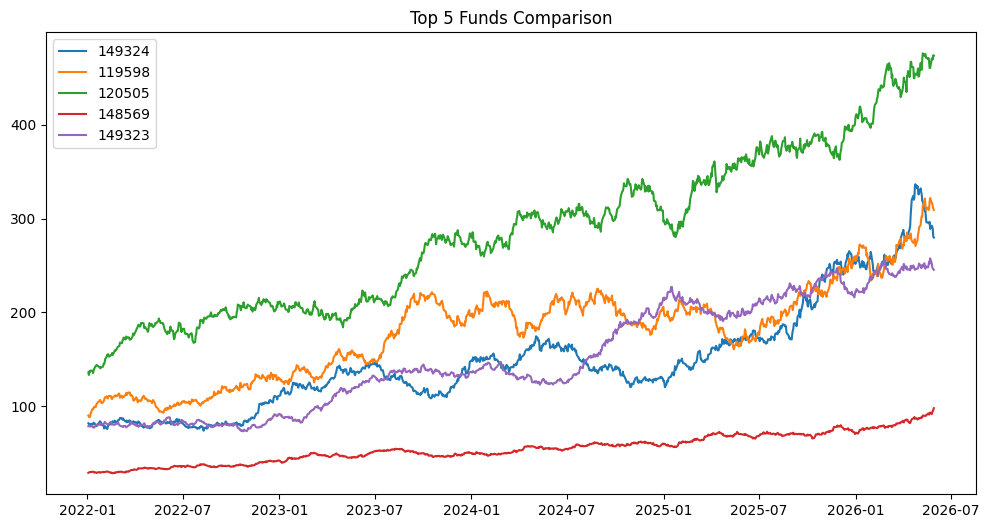

In [11]:
top5 = (
    scorecard
    .head(5)["amfi_code"]
    .tolist()
)

plt.figure(figsize=(12,6))

for code in top5:

    temp = nav[
        nav["amfi_code"] == code
    ]

    plt.plot(
        temp["date"],
        temp["nav"],
        label=str(code)
    )

plt.legend()

plt.title(
    "Top 5 Funds Comparison"
)

plt.savefig(
    "../reports/benchmark_comparison.png"
)

plt.show()